# Лабораторная работа №3  
## Понижение размерности

**Дисциплина:** Интеллектуальный анализ данных  
**Датасет:** `lab3_dimensionality_dataset.csv`

В работе используется синтетический датасет с 700 объектами.  
В датасете есть:

- числовые признаки для PCA, t-SNE и UMAP;
- категориальный столбец `customer_segment`, который используется только для раскраски графиков;
- идентификатор `customer_id`, который не участвует в анализе;
- пропуски в части числовых признаков;
- выбросы и коррелированные признаки.

Цель работы — исследовать геометрию данных, реализовать PCA вручную, сравнить его с `sklearn`, построить визуализации и оценить качество сжатия данных.

In [1]:
import os
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

try:
    import umap.umap_ as umap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap.umap_ as umap

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.4f}'.format)

RANDOM_STATE = 42

## 1. Загрузка данных и первичное профилирование

Загрузим CSV-файл.  
Для лабораторной работы числовыми признаками считаются все числовые столбцы.  
Столбцы `customer_id` и `customer_segment` не используются как признаки для PCA, t-SNE и UMAP.

In [2]:
DATA_PATH = 'lab3_dimensionality_dataset.csv'
df = pd.read_csv(DATA_PATH)

print('Первые строки датасета:')
display(df.head())

print('Размер датасета:', df.shape)

Первые строки датасета:


,customer_id,customer_segment,age,annual_income,monthly_expenses,monthly_savings,credit_score,debt_ratio,monthly_purchases,avg_order_value,site_visits,app_sessions,support_tickets,satisfaction_score,loyalty_score,churn_risk,time_on_platform_months,promo_response_rate,returns_count,delivery_delay_days,device_score,engagement_index
0,C0416,premium,43.0000,"49,537.8700","2,012.5700","2,367.3800",690.0000,0.2980,9.0000,46.0500,49.0000,26.0000,2.0000,7.7300,54.8300,15.3100,29.0000,0.1670,3.0000,1.8300,74.0200,50.9300
1,C0509,premium,32.0000,"61,281.1200","2,536.3700","2,932.7400",711.0000,0.1450,14.0000,63.1900,61.0000,42.0000,0.0000,9.1900,80.8200,0.0000,45.0000,0.3120,2.0000,1.4000,76.8100,65.4400
2,C0244,standard,45.0000,"38,791.4400","1,572.3400","1,479.9500",570.0000,0.4600,9.0000,50.9100,53.0000,31.0000,3.0000,6.6700,54.7200,34.5700,21.0000,0.2330,3.0000,2.4900,51.3800,54.8100
3,C0186,standard,43.0000,"55,760.8300","2,356.6700","2,537.1400",703.0000,0.2510,16.0000,55.4700,78.0000,69.0000,1.0000,10.0000,87.0400,0.0000,43.0000,0.3710,4.0000,1.2700,68.4600,100.0000
4,C0643,risk_group,40.0000,"46,410.2200","1,865.0000","1,992.7500",624.0000,0.4390,8.0000,45.6300,31.0000,38.0000,3.0000,6.4700,62.1900,43.6500,28.0000,0.2650,1.0000,2.2000,68.2000,54.8400


Размер датасета: (700, 22)


In [3]:
print('Информация о датасете:')
print()
df.info()

Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              700 non-null    object 
 1   customer_segment         700 non-null    object 
 2   age                      700 non-null    float64
 3   annual_income            695 non-null    float64
 4   monthly_expenses         700 non-null    float64
 5   monthly_savings          694 non-null    float64
 6   credit_score             693 non-null    float64
 7   debt_ratio               700 non-null    float64
 8   monthly_purchases        700 non-null    float64
 9   avg_order_value          700 non-null    float64
 10  site_visits              700 non-null    float64
 11  app_sessions             694 non-null    float64
 12  support_tickets          695 non-null    float64
 13  satisfaction_score       694 non-null    float64
 14  lo

In [4]:
print('Количество объектов:', df.shape[0])
print('Общее количество столбцов:', df.shape[1])

id_col = 'customer_id'
segment_col = 'customer_segment'

numeric_features = df.select_dtypes(include=np.number).columns.tolist()

print('Количество числовых признаков:', len(numeric_features))
print('Числовые признаки:')
for col in numeric_features:
    print('-', col)

Количество объектов: 700
Общее количество столбцов: 22
Количество числовых признаков: 20
Числовые признаки:
- age
- annual_income
- monthly_expenses
- monthly_savings
- credit_score
- debt_ratio
- monthly_purchases
- avg_order_value
- site_visits
- app_sessions
- support_tickets
- satisfaction_score
- loyalty_score
- churn_risk
- time_on_platform_months
- promo_response_rate
- returns_count
- delivery_delay_days
- device_score
- engagement_index


In [5]:
print('Описательные статистики по числовым признакам:')
display(df[numeric_features].describe().T)

Описательные статистики по числовым признакам:


,count,mean,std,min,25%,50%,75%,max
age,700.0000,37.5200,6.6275,18.0000,33.0000,37.0000,42.0000,59.0000
annual_income,695.0000,"41,244.7660","18,612.2657","9,000.0000","27,493.6200","39,599.4700","54,370.6150","119,824.4000"
monthly_expenses,700.0000,"1,685.0670",788.4069,250.0000,"1,091.5300","1,642.1350","2,225.4800","4,501.9000"
monthly_savings,694.0000,"1,652.4384","1,169.5422",-830.3600,775.1300,"1,477.7800","2,513.9700","5,142.2400"
credit_score,693.0000,623.7951,95.4439,406.0000,554.0000,615.0000,695.0000,850.0000
debt_ratio,700.0000,0.3820,0.1758,0.0200,0.2605,0.3830,0.5102,0.8970
monthly_purchases,700.0000,11.0129,6.0806,0.0000,6.0000,11.0000,16.0000,26.0000
avg_order_value,700.0000,47.6502,13.0003,10.9400,38.8600,46.8100,55.7475,128.6200
site_visits,700.0000,54.3586,27.5964,0.0000,34.0000,53.0000,74.2500,203.0000
app_sessions,694.0000,35.7478,24.0337,0.0000,17.0000,33.5000,53.7500,147.0000


In [6]:
print('Количество пропусков по столбцам:')
missing_table = df.isna().sum().sort_values(ascending=False)
display(missing_table[missing_table > 0])

print('Всего пропущенных значений:', int(df.isna().sum().sum()))

Количество пропусков по столбцам:


,0
credit_score,7
monthly_savings,6
loyalty_score,6
satisfaction_score,6
app_sessions,6
annual_income,5
delivery_delay_days,5
support_tickets,5


Всего пропущенных значений: 46


### Подготовка рабочей версии данных

Для PCA, t-SNE и UMAP нельзя напрямую использовать пропуски.  
В этой работе пропуски в числовых признаках заполняются медианой соответствующего признака.

Медиана выбрана потому, что она устойчивее к выбросам, чем среднее значение.

In [7]:
X_raw = df[numeric_features].copy()

# Заполнение пропусков медианами числовых признаков
X_filled = X_raw.fillna(X_raw.median(numeric_only=True))

print('Пропуски после заполнения:')
print(int(X_filled.isna().sum().sum()))

display(X_filled.head())

Пропуски после заполнения:
0


,age,annual_income,monthly_expenses,monthly_savings,credit_score,debt_ratio,monthly_purchases,avg_order_value,site_visits,app_sessions,support_tickets,satisfaction_score,loyalty_score,churn_risk,time_on_platform_months,promo_response_rate,returns_count,delivery_delay_days,device_score,engagement_index
0,43.0000,"49,537.8700","2,012.5700","2,367.3800",690.0000,0.2980,9.0000,46.0500,49.0000,26.0000,2.0000,7.7300,54.8300,15.3100,29.0000,0.1670,3.0000,1.8300,74.0200,50.9300
1,32.0000,"61,281.1200","2,536.3700","2,932.7400",711.0000,0.1450,14.0000,63.1900,61.0000,42.0000,0.0000,9.1900,80.8200,0.0000,45.0000,0.3120,2.0000,1.4000,76.8100,65.4400
2,45.0000,"38,791.4400","1,572.3400","1,479.9500",570.0000,0.4600,9.0000,50.9100,53.0000,31.0000,3.0000,6.6700,54.7200,34.5700,21.0000,0.2330,3.0000,2.4900,51.3800,54.8100
3,43.0000,"55,760.8300","2,356.6700","2,537.1400",703.0000,0.2510,16.0000,55.4700,78.0000,69.0000,1.0000,10.0000,87.0400,0.0000,43.0000,0.3710,4.0000,1.2700,68.4600,100.0000
4,40.0000,"46,410.2200","1,865.0000","1,992.7500",624.0000,0.4390,8.0000,45.6300,31.0000,38.0000,3.0000,6.4700,62.1900,43.6500,28.0000,0.2650,1.0000,2.2000,68.2000,54.8400


## Задание 1. Геометрия данных в пространстве признаков

Построим гистограммы распределения признаков и матрицу корреляций.

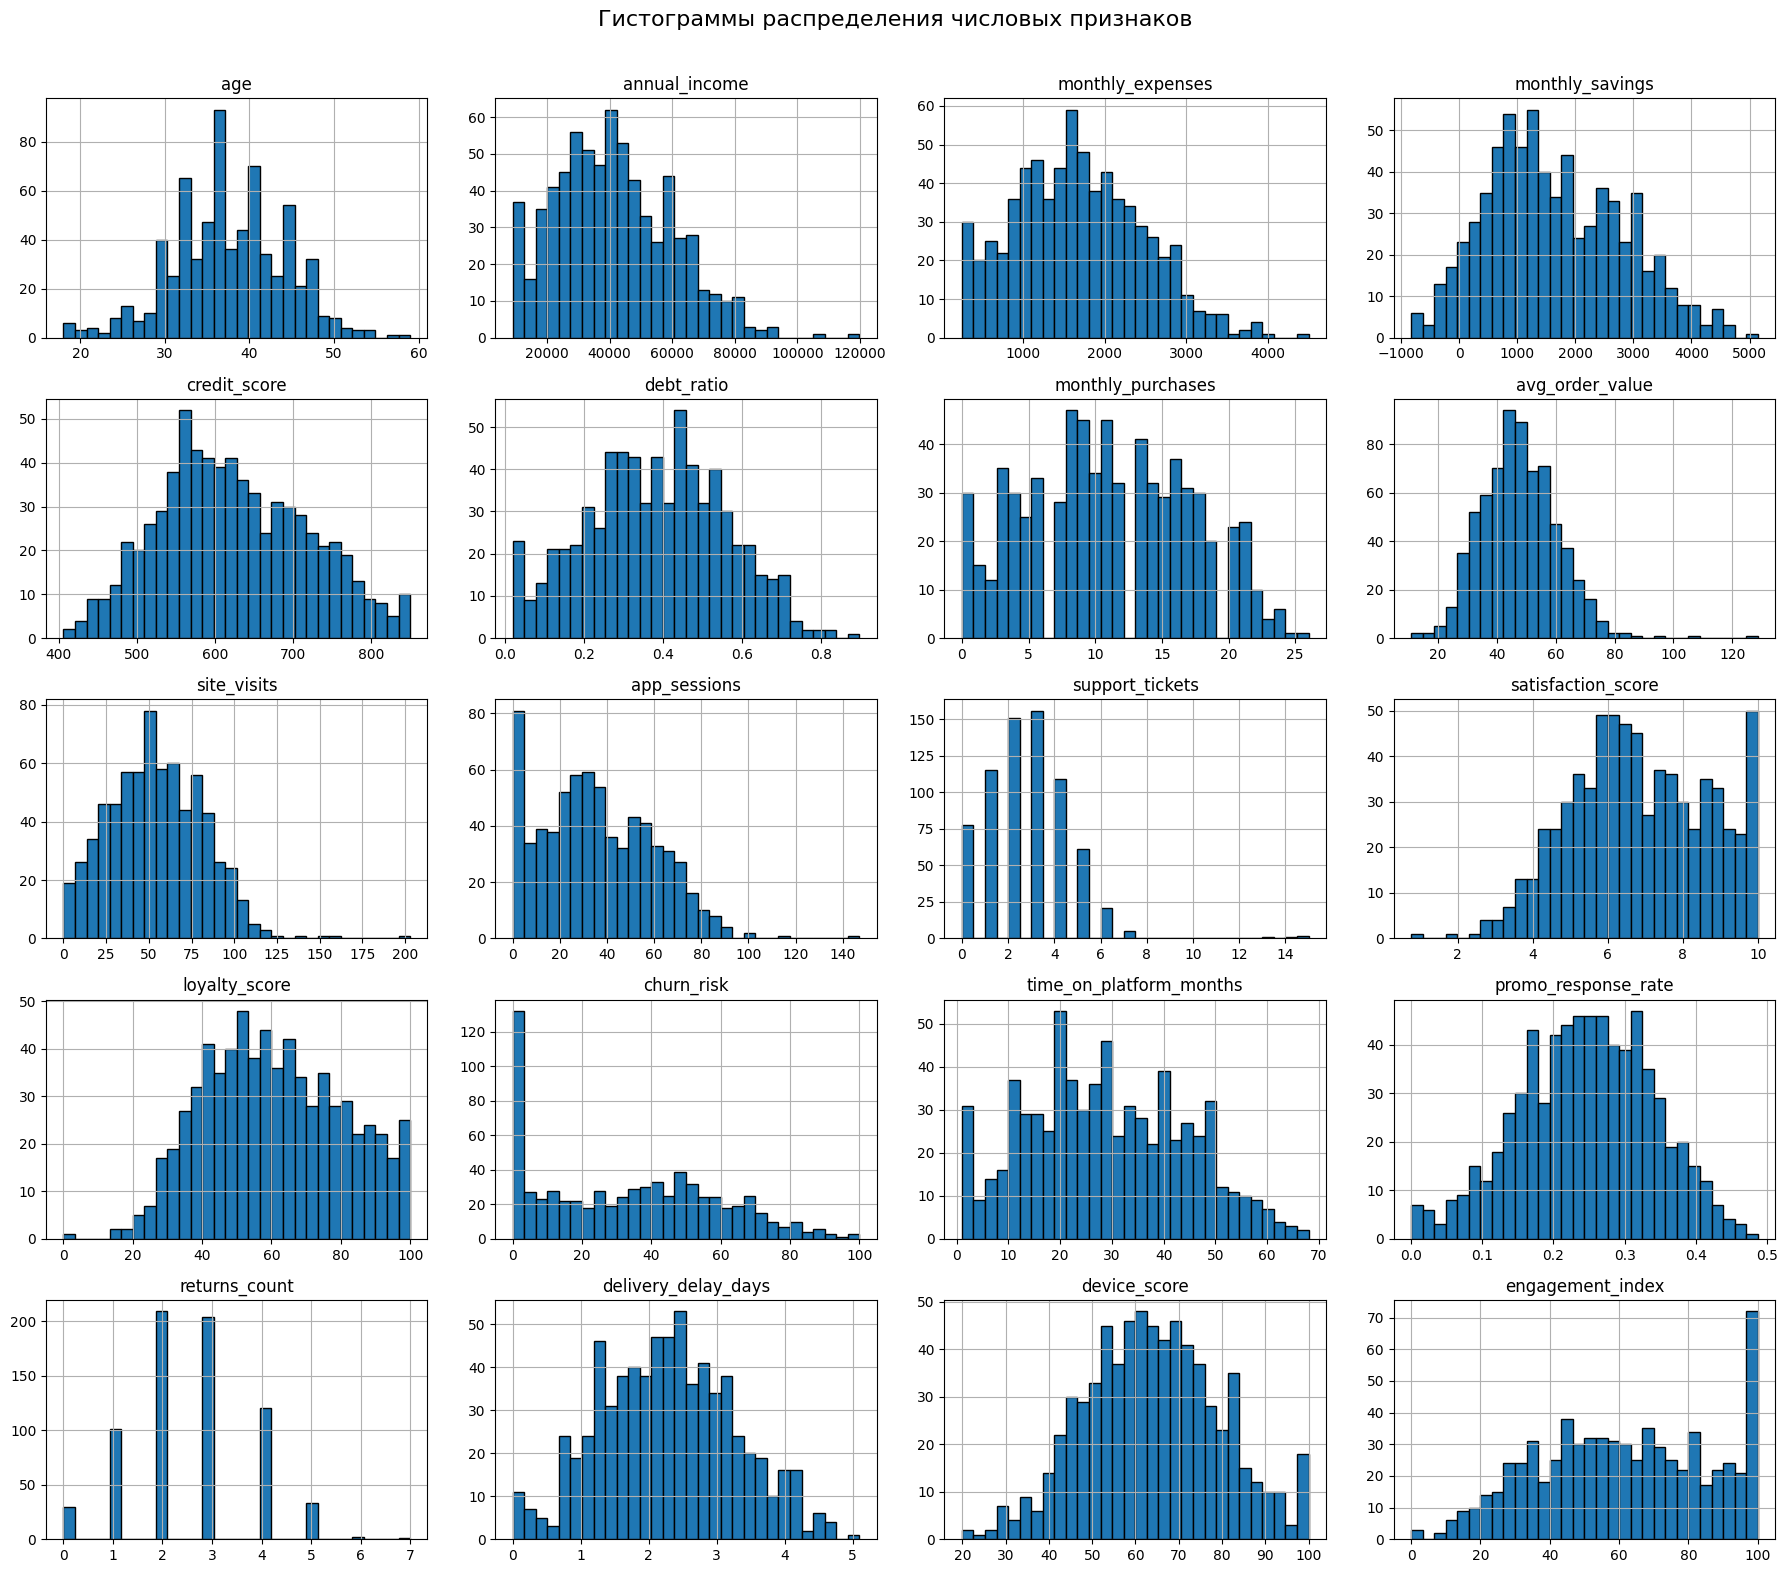

In [8]:
# Гистограммы всех числовых признаков
axes = X_filled.hist(bins=30, figsize=(18, 16), edgecolor='black')
plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

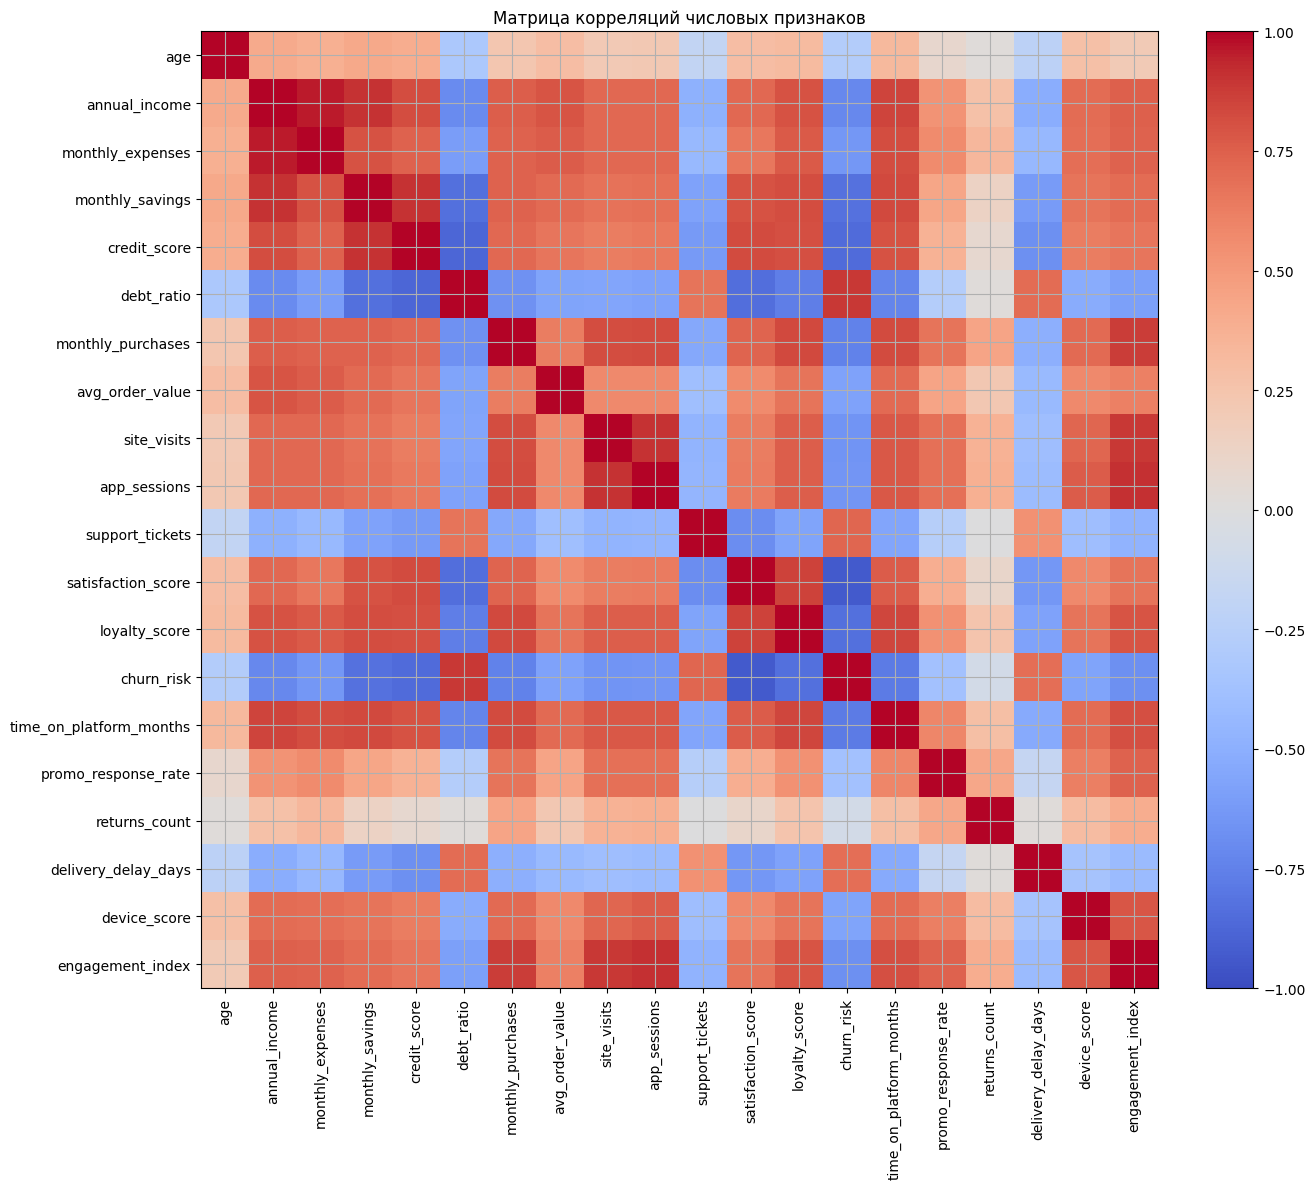

In [9]:
# Матрица корреляций
corr_matrix = X_filled.corr()

plt.figure(figsize=(14, 12))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

In [10]:
# Найдём пары признаков с сильной корреляцией.
# В работе будем считать сильной корреляцией |r| >= 0.70.
strong_corr = []

for i in range(len(numeric_features)):
    for j in range(i + 1, len(numeric_features)):
        feature_1 = numeric_features[i]
        feature_2 = numeric_features[j]
        value = corr_matrix.loc[feature_1, feature_2]
        if abs(value) >= 0.70:
            strong_corr.append([feature_1, feature_2, value])

strong_corr_df = pd.DataFrame(strong_corr, columns=['Признак 1', 'Признак 2', 'Корреляция'])
strong_corr_df['|Корреляция|'] = strong_corr_df['Корреляция'].abs()
strong_corr_df = strong_corr_df.sort_values('|Корреляция|', ascending=False).drop(columns='|Корреляция|')

print('Количество пар с |корреляцией| >= 0.70:', len(strong_corr_df))
display(strong_corr_df.head(20))

Количество пар с |корреляцией| >= 0.70: 69


,Признак 1,Признак 2,Корреляция
0,annual_income,monthly_expenses,0.9605
59,satisfaction_score,churn_risk,-0.9339
56,app_sessions,engagement_index,0.9114
1,annual_income,monthly_savings,0.9041
48,site_visits,app_sessions,0.8991
21,monthly_savings,credit_score,0.8985
37,debt_ratio,churn_risk,0.8884
52,site_visits,engagement_index,0.8871
29,credit_score,debt_ratio,-0.8774
46,monthly_purchases,engagement_index,0.8700


### Вывод по заданию 1

В датасете есть сильно коррелированные признаки. Например, ожидаемо связаны финансовые признаки, активность пользователя и признаки лояльности.  
Это означает, что часть признаков может содержать избыточную информацию.

PCA как раз подходит для такой ситуации: он строит новые признаки — главные компоненты, которые являются линейными комбинациями исходных признаков и позволяют компактнее описать данные.

## Задание 2. Реализация PCA с нуля на NumPy

Алгоритм PCA включает следующие шаги:

1. стандартизация данных;
2. вычисление ковариационной матрицы;
3. нахождение собственных значений и собственных векторов;
4. сортировка компонент по убыванию собственных значений;
5. проекция данных на первые `k` компонент.

Для PCA важна стандартизация, потому что признаки имеют разные единицы измерения: возраст, доход, количество покупок, оценки и т.д.

In [11]:
# 1. Стандартизация данных
X_mean = X_filled.mean(axis=0)
X_std = X_filled.std(axis=0, ddof=0)
X_scaled_manual = (X_filled - X_mean) / X_std

print('Средние значения после стандартизации:')
display(X_scaled_manual.mean(axis=0).round(6).to_frame('mean'))

print('Стандартные отклонения после стандартизации:')
display(X_scaled_manual.std(axis=0, ddof=0).round(6).to_frame('std'))

Средние значения после стандартизации:


,mean
age,-0.0000
annual_income,0.0000
monthly_expenses,-0.0000
monthly_savings,0.0000
credit_score,-0.0000
debt_ratio,0.0000
monthly_purchases,-0.0000
avg_order_value,0.0000
site_visits,-0.0000
app_sessions,0.0000


Стандартные отклонения после стандартизации:


,std
age,1.0000
annual_income,1.0000
monthly_expenses,1.0000
monthly_savings,1.0000
credit_score,1.0000
debt_ratio,1.0000
monthly_purchases,1.0000
avg_order_value,1.0000
site_visits,1.0000
app_sessions,1.0000


In [12]:
# 2. Ковариационная матрица
cov_matrix = np.cov(X_scaled_manual, rowvar=False)

print('Размер ковариационной матрицы:', cov_matrix.shape)
display(pd.DataFrame(cov_matrix, index=numeric_features, columns=numeric_features).round(4))

Размер ковариационной матрицы: (20, 20)


,age,annual_income,monthly_expenses,monthly_savings,credit_score,debt_ratio,monthly_purchases,avg_order_value,site_visits,app_sessions,support_tickets,satisfaction_score,loyalty_score,churn_risk,time_on_platform_months,promo_response_rate,returns_count,delivery_delay_days,device_score,engagement_index
age,1.0014,0.4089,0.3788,0.4192,0.3949,-0.3189,0.2270,0.2917,0.2059,0.2144,-0.1818,0.2901,0.3126,-0.2805,0.3254,0.0842,0.0203,-0.2202,0.2789,0.1986
annual_income,0.4089,1.0014,0.9619,0.9054,0.8195,-0.7002,0.7568,0.7975,0.7156,0.7175,-0.4891,0.7179,0.8047,-0.7151,0.8476,0.5315,0.2695,-0.5087,0.7004,0.7441
monthly_expenses,0.3788,0.9619,1.0014,0.8043,0.7415,-0.6088,0.7425,0.7594,0.7162,0.7169,-0.4332,0.6510,0.7693,-0.6415,0.8182,0.5667,0.3291,-0.4397,0.6900,0.7379
monthly_savings,0.4192,0.9054,0.8043,1.0014,0.8998,-0.8307,0.7371,0.7110,0.6788,0.6838,-0.5765,0.8020,0.8184,-0.8222,0.8358,0.4347,0.1317,-0.6130,0.6715,0.7000
credit_score,0.3949,0.8195,0.7415,0.8998,1.0014,-0.8786,0.7195,0.6576,0.6277,0.6471,-0.6254,0.8279,0.8076,-0.8570,0.7988,0.3629,0.0719,-0.6750,0.6307,0.6628
debt_ratio,-0.3189,-0.7002,-0.6088,-0.8307,-0.8786,1.0014,-0.6727,-0.5650,-0.5595,-0.5716,0.6685,-0.8443,-0.7625,0.8897,-0.7311,-0.2719,0.0173,0.7002,-0.5228,-0.5880
monthly_purchases,0.2270,0.7568,0.7425,0.7371,0.7195,-0.6727,1.0014,0.6316,0.8207,0.8275,-0.5462,0.7323,0.8329,-0.7494,0.8238,0.6672,0.4443,-0.5007,0.7107,0.8713
avg_order_value,0.2917,0.7975,0.7594,0.7110,0.6576,-0.5650,0.6316,1.0014,0.5737,0.5771,-0.3852,0.5636,0.6680,-0.5777,0.7091,0.4411,0.2227,-0.4233,0.5754,0.6131
site_visits,0.2059,0.7156,0.7162,0.6788,0.6277,-0.5595,0.8207,0.5737,1.0014,0.9004,-0.4672,0.6297,0.7550,-0.6500,0.7752,0.6834,0.3622,-0.3979,0.7228,0.8884
app_sessions,0.2144,0.7175,0.7169,0.6838,0.6471,-0.5716,0.8275,0.5771,0.9004,1.0014,-0.4609,0.6367,0.7580,-0.6427,0.7785,0.6812,0.3817,-0.4096,0.7622,0.9127


In [13]:
# 3. Собственные значения и собственные векторы
# eigh используется для симметричных матриц, а ковариационная матрица как раз симметрична.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 4. Сортировка по убыванию собственных значений
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

explained_variance_ratio_manual = eigenvalues / eigenvalues.sum()
cumulative_variance_manual = np.cumsum(explained_variance_ratio_manual)

pca_info_manual = pd.DataFrame({
    'component': [f'PC{i + 1}' for i in range(len(eigenvalues))],
    'eigenvalue': eigenvalues,
    'explained_variance_ratio': explained_variance_ratio_manual,
    'cumulative_variance': cumulative_variance_manual
})

display(pca_info_manual)

,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,PC1,12.6994,0.6341,0.6341
1,PC2,2.1413,0.1069,0.7410
2,PC3,1.0970,0.0548,0.7957
3,PC4,0.6519,0.0325,0.8283
4,PC5,0.6493,0.0324,0.8607
5,PC6,0.4575,0.0228,0.8836
6,PC7,0.3871,0.0193,0.9029
7,PC8,0.3341,0.0167,0.9196
8,PC9,0.3045,0.0152,0.9348
9,PC10,0.2662,0.0133,0.9481


In [14]:
# 5. Проекция данных на первые k компонент
k = 2
components_k = eigenvectors[:, :k]
X_pca_manual_2d = X_scaled_manual.values @ components_k

pca_manual_df = pd.DataFrame(X_pca_manual_2d, columns=['PC1_manual', 'PC2_manual'])
pca_manual_df[segment_col] = df[segment_col].values

display(pca_manual_df.head())

,PC1_manual,PC2_manual,customer_segment
0,0.7736,-1.2410,premium
1,3.6706,-1.2356,premium
2,-0.8799,0.0486,standard
3,4.3835,0.3716,standard
4,-0.4088,-0.5652,risk_group


### Сравнение ручной реализации PCA с sklearn

Сравним собственные значения и доли объяснённой дисперсии с `sklearn.decomposition.PCA`.  
Знаки главных компонент могут отличаться, потому что собственный вектор можно умножить на `-1`, и он всё равно останется тем же направлением.

In [15]:
# Для сравнения используем StandardScaler из sklearn.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

pca_sklearn = PCA(n_components=len(numeric_features), random_state=RANDOM_STATE)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

comparison_df = pd.DataFrame({
    'component': [f'PC{i + 1}' for i in range(len(numeric_features))],
    'manual_eigenvalue': eigenvalues,
    'sklearn_explained_variance': pca_sklearn.explained_variance_,
    'manual_explained_variance_ratio': explained_variance_ratio_manual,
    'sklearn_explained_variance_ratio': pca_sklearn.explained_variance_ratio_
})

comparison_df['difference_ratio'] = (
    comparison_df['manual_explained_variance_ratio'] - comparison_df['sklearn_explained_variance_ratio']
).abs()

display(comparison_df)

print('Максимальное отличие долей объяснённой дисперсии:', comparison_df['difference_ratio'].max())

,component,manual_eigenvalue,sklearn_explained_variance,manual_explained_variance_ratio,sklearn_explained_variance_ratio,difference_ratio
0,PC1,12.6994,12.6994,0.6341,0.6341,0.0000
1,PC2,2.1413,2.1413,0.1069,0.1069,0.0000
2,PC3,1.0970,1.0970,0.0548,0.0548,0.0000
3,PC4,0.6519,0.6519,0.0325,0.0325,0.0000
4,PC5,0.6493,0.6493,0.0324,0.0324,0.0000
5,PC6,0.4575,0.4575,0.0228,0.0228,0.0000
6,PC7,0.3871,0.3871,0.0193,0.0193,0.0000
7,PC8,0.3341,0.3341,0.0167,0.0167,0.0000
8,PC9,0.3045,0.3045,0.0152,0.0152,0.0000
9,PC10,0.2662,0.2662,0.0133,0.0133,0.0000


Максимальное отличие долей объяснённой дисперсии: 2.220446049250313e-16


In [16]:
# Проверим близость первых двух компонент через корреляцию.
# Используем модуль корреляции, потому что знак компоненты может быть противоположным.
for i in range(2):
    corr_value = np.corrcoef(X_pca_manual_2d[:, i], X_pca_sklearn[:, i])[0, 1]
    print(f'Корреляция manual PC{i + 1} и sklearn PC{i + 1}: {corr_value:.6f}')
    print(f'Модуль корреляции: {abs(corr_value):.6f}')

Корреляция manual PC1 и sklearn PC1: 1.000000
Модуль корреляции: 1.000000
Корреляция manual PC2 и sklearn PC2: 1.000000
Модуль корреляции: 1.000000


### 2.1 Исследование объяснённой дисперсии

Построим графики:

- доля объяснённой дисперсии каждой компоненты;
- накопленная объяснённая дисперсия.

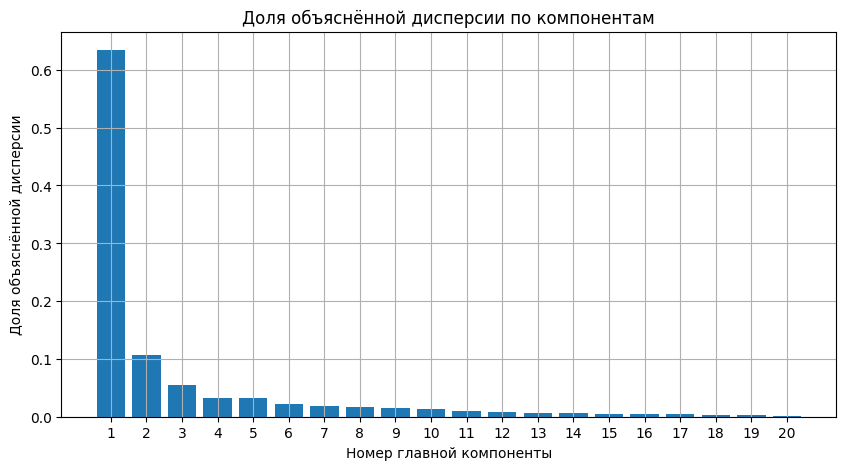

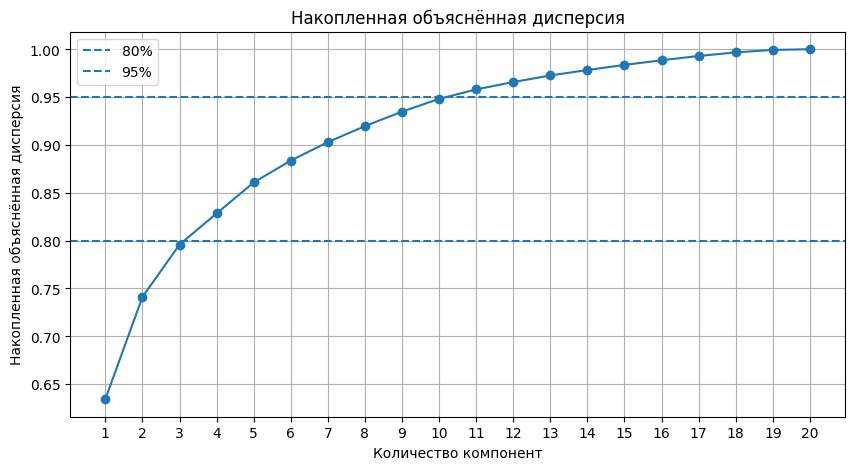

In [17]:
components_numbers = np.arange(1, len(numeric_features) + 1)

plt.figure(figsize=(10, 5))
plt.bar(components_numbers, pca_sklearn.explained_variance_ratio_)
plt.xticks(components_numbers)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Доля объяснённой дисперсии по компонентам')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(components_numbers, np.cumsum(pca_sklearn.explained_variance_ratio_), marker='o')
plt.axhline(0.80, linestyle='--', label='80%')
plt.axhline(0.95, linestyle='--', label='95%')
plt.xticks(components_numbers)
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Накопленная объяснённая дисперсия')
plt.legend()
plt.show()

In [18]:
cumulative_variance = np.cumsum(pca_sklearn.explained_variance_ratio_)
components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print('Компонент для объяснения 80% дисперсии:', components_80)
print('Компонент для объяснения 95% дисперсии:', components_95)

Компонент для объяснения 80% дисперсии: 4
Компонент для объяснения 95% дисперсии: 11


### Вывод по заданию 2

PCA удалось реализовать вручную через NumPy.  
Результаты ручной реализации совпадают с `sklearn.decomposition.PCA` по объяснённой дисперсии.

Для данного датасета:

- около 80% дисперсии объясняют первые 4 компоненты;
- около 95% дисперсии объясняют первые 11 компонент.

Это показывает, что исходные 20 числовых признаков можно заметно сжать без полной потери структуры данных.

## Задание 3. Интерпретация главных компонент

Рассмотрим первые три главные компоненты.  
Коэффициенты компоненты показывают, какой вклад в новую ось вносит каждый исходный признак.

Чем больше модуль коэффициента, тем сильнее признак влияет на компоненту.

In [19]:
loadings = pd.DataFrame(
    pca_sklearn.components_[:3].T,
    index=numeric_features,
    columns=['PC1', 'PC2', 'PC3']
)

print('Коэффициенты признаков в первых трёх главных компонентах:')
display(loadings)

Коэффициенты признаков в первых трёх главных компонентах:


,PC1,PC2,PC3
age,0.1024,-0.1367,0.6940
annual_income,0.2548,0.0171,0.2691
monthly_expenses,0.2432,0.0942,0.2751
monthly_savings,0.2556,-0.1326,0.1535
credit_score,0.2494,-0.2105,0.0652
debt_ratio,-0.2316,0.2995,0.0840
monthly_purchases,0.2519,0.1424,-0.1366
avg_order_value,0.2119,0.0290,0.2703
site_visits,0.2368,0.2170,-0.1269
app_sessions,0.2392,0.2222,-0.1195


In [20]:
for component in ['PC1', 'PC2', 'PC3']:
    print(component)
    top_features = loadings[component].abs().sort_values(ascending=False).head(7)
    display(pd.DataFrame({
        'feature': top_features.index,
        'absolute_loading': top_features.values,
        'loading': loadings.loc[top_features.index, component].values
    }))
    print()

PC1


,feature,absolute_loading,loading
0,time_on_platform_months,0.2587,0.2587
1,loyalty_score,0.2575,0.2575
2,monthly_savings,0.2556,0.2556
3,annual_income,0.2548,0.2548
4,monthly_purchases,0.2519,0.2519
5,credit_score,0.2494,0.2494
6,engagement_index,0.2465,0.2465



PC2


,feature,absolute_loading,loading
0,returns_count,0.4576,0.4576
1,promo_response_rate,0.3883,0.3883
2,delivery_delay_days,0.3126,0.3126
3,debt_ratio,0.2995,0.2995
4,support_tickets,0.2471,0.2471
5,churn_risk,0.2322,0.2322
6,engagement_index,0.2271,0.2271



PC3


,feature,absolute_loading,loading
0,age,0.6940,0.6940
1,support_tickets,0.3114,0.3114
2,monthly_expenses,0.2751,0.2751
3,avg_order_value,0.2703,0.2703
4,annual_income,0.2691,0.2691
5,churn_risk,0.1810,0.1810
6,satisfaction_score,0.1542,-0.1542


### Вывод по заданию 3

Первая главная компонента сильнее всего связана с признаками общей ценности и активности клиента: временем на платформе, лояльностью, сбережениями, доходом, покупками и кредитным рейтингом.  
Поэтому её можно интерпретировать как условный интегральный показатель «финансовой устойчивости и вовлечённости клиента».

Вторая компонента сильнее связана с возвратами, реакцией на промо, задержками доставки, долговой нагрузкой и обращениями в поддержку.  
Её можно интерпретировать как направление, связанное с проблемностью или нестабильностью клиентского поведения.

Третья компонента заметно связана с возрастом и рядом дополнительных финансово-поведенческих признаков.  
Признаки с маленькими коэффициентами в первых компонентах вносят меньший вклад именно в первые направления максимальной дисперсии.

## Задание 4. Визуализация данных

Сравним две визуализации:

1. по двум исходным признакам;
2. по двум главным компонентам PCA.

Цвет точки показывает `customer_segment`.  
Этот столбец не используется при обучении PCA, а нужен только для визуальной проверки структуры.

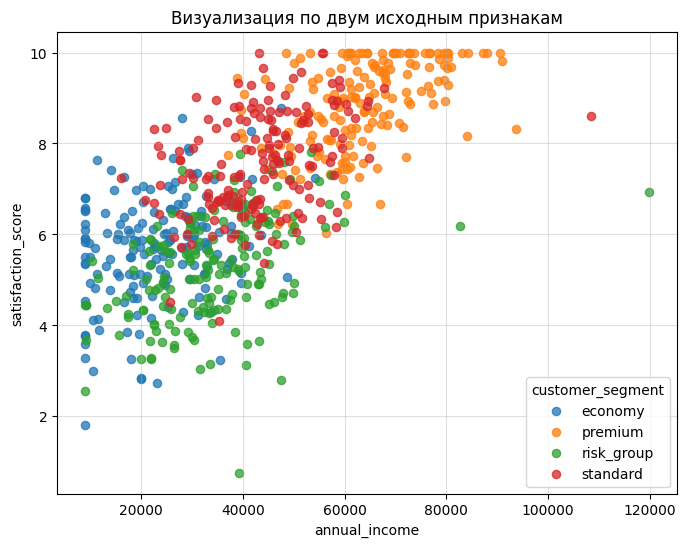

In [21]:
segment_categories = sorted(df[segment_col].dropna().unique())
base_cmap = plt.get_cmap('tab10')
segment_colors = {
    segment: base_cmap(i) for i, segment in enumerate(segment_categories)
}


def plot_by_segment(ax, x, y, title, xlabel, ylabel, legend=True):
    x_values = np.asarray(x)
    y_values = np.asarray(y)
    segments = df[segment_col].values

    for segment in segment_categories:
        mask = segments == segment
        ax.scatter(
            x_values[mask],
            y_values[mask],
            color=segment_colors[segment],
            label=segment,
            alpha=0.75,
            s=35
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.4)

    if legend:
        ax.legend(title='customer_segment', loc='best')


plt.figure(figsize=(8, 6))
ax = plt.gca()
plot_by_segment(
    ax,
    X_filled['annual_income'],
    X_filled['satisfaction_score'],
    title='Визуализация по двум исходным признакам',
    xlabel='annual_income',
    ylabel='satisfaction_score',
    legend=True
)
plt.show()

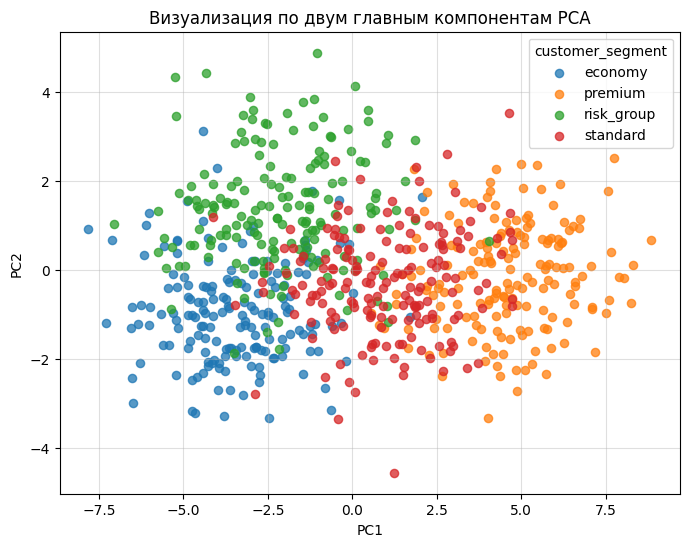

In [22]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
ax = plt.gca()
plot_by_segment(
    ax,
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    title='Визуализация по двум главным компонентам PCA',
    xlabel='PC1',
    ylabel='PC2',
    legend=True
)
plt.show()

### Вывод по заданию 4

Визуализация по двум исходным признакам показывает только частный срез данных.  
Например, если взять `annual_income` и `satisfaction_score`, то остальные 18 признаков вообще не учитываются.

В пространстве первых двух главных компонент учитывается информация сразу из всех числовых признаков.  
Поэтому структура групп может быть заметнее: PCA выбирает направления, в которых данные имеют наибольшую дисперсию.

Однако PCA остаётся линейным методом. Если структура данных нелинейная, то t-SNE или UMAP могут показать группы лучше.

## Задание 5. Нелинейные методы снижения размерности

Используем два метода:

- t-SNE;
- UMAP.

Оба метода строят двумерные проекции, но делают это иначе, чем PCA.  
PCA ищет линейные направления максимальной дисперсии, а t-SNE и UMAP стараются сохранить соседство объектов.

### 5.1 Исследование параметров t-SNE

Для t-SNE изменим параметр `perplexity`: `5`, `30`, `50`.

`perplexity` влияет на то, сколько соседей метод условно учитывает при построении локальной структуры.

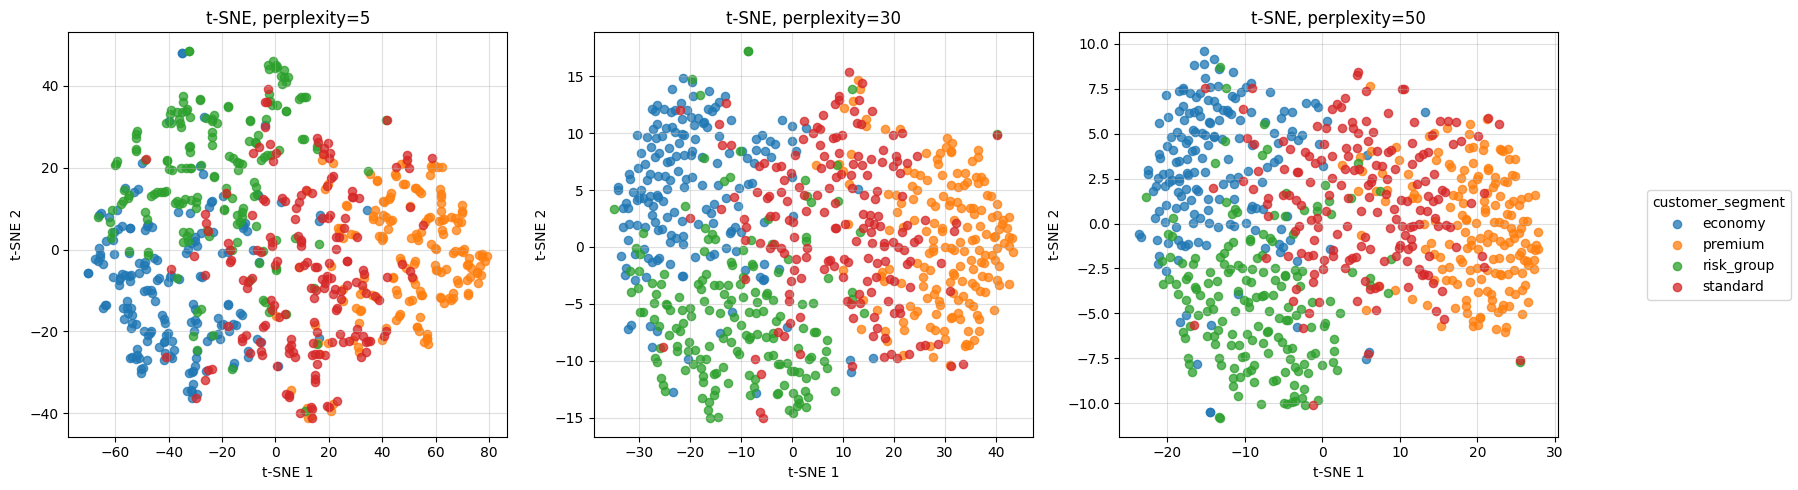

In [23]:
TSNE_MAX_ITER = 700

def run_tsne(perplexity):
    """Запуск t-SNE с учётом различий в версиях scikit-learn."""
    params = {
        'n_components': 2,
        'perplexity': perplexity,
        'learning_rate': 'auto',
        'init': 'pca',
        'random_state': RANDOM_STATE
    }

    # В новых версиях sklearn используется max_iter, в старых — n_iter.
    try:
        return TSNE(**params, max_iter=TSNE_MAX_ITER).fit_transform(X_scaled)
    except TypeError:
        return TSNE(**params, n_iter=TSNE_MAX_ITER).fit_transform(X_scaled)


tsne_results = {}

for perplexity in [5, 30, 50]:
    tsne_results[perplexity] = run_tsne(perplexity)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perplexity in zip(axes, [5, 30, 50]):
    embedding = tsne_results[perplexity]
    plot_by_segment(
        ax,
        embedding[:, 0],
        embedding[:, 1],
        title=f't-SNE, perplexity={perplexity}',
        xlabel='t-SNE 1',
        ylabel='t-SNE 2',
        legend=False
    )

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='customer_segment', loc='center right')
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

### 5.2 Исследование параметров UMAP

Для UMAP изменим параметры:

- `n_neighbors` — сколько соседей учитывать при построении структуры;
- `min_dist` — насколько плотно могут располагаться точки в итоговой проекции.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


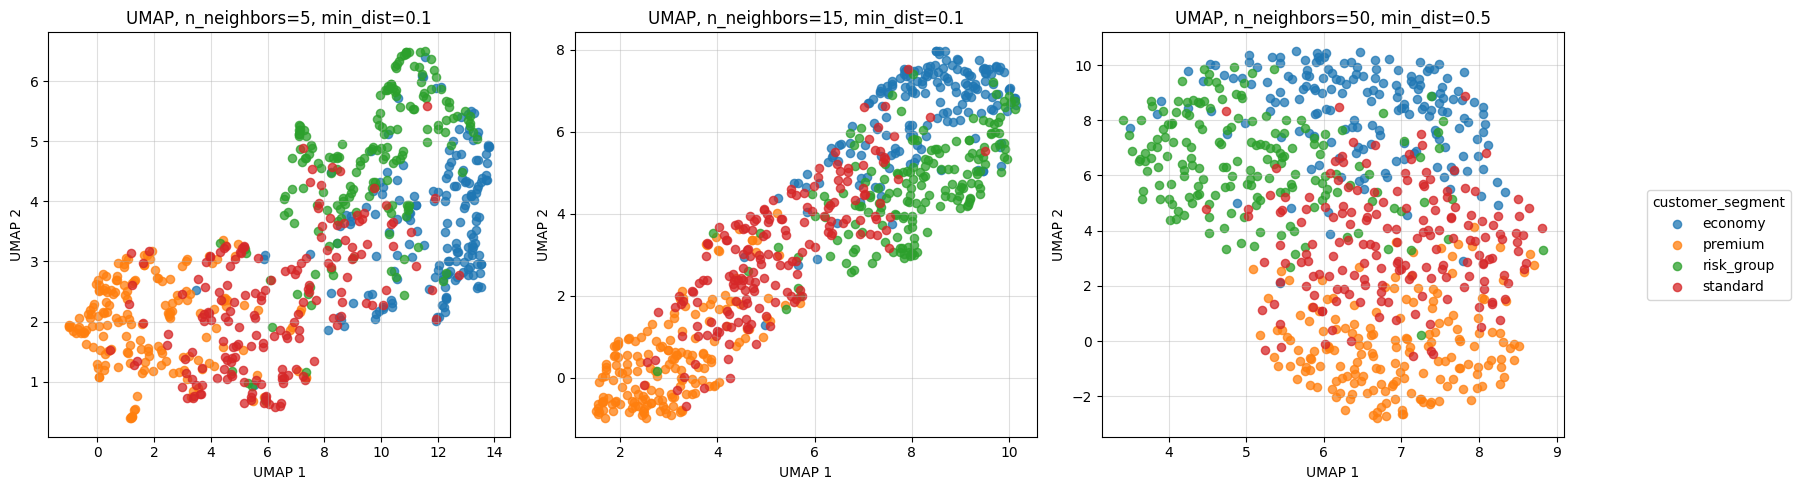

In [24]:
umap_params = [
    (5, 0.10),
    (15, 0.10),
    (50, 0.50)
]

umap_results = {}

for n_neighbors, min_dist in umap_params:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=RANDOM_STATE
    )
    umap_results[(n_neighbors, min_dist)] = reducer.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, params in zip(axes, umap_params):
    n_neighbors, min_dist = params
    embedding = umap_results[params]
    plot_by_segment(
        ax,
        embedding[:, 0],
        embedding[:, 1],
        title=f'UMAP, n_neighbors={n_neighbors}, min_dist={min_dist}',
        xlabel='UMAP 1',
        ylabel='UMAP 2',
        legend=False
    )

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='customer_segment', loc='center right')
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

### Вывод по заданию 5

При малом `perplexity` в t-SNE сильнее подчёркиваются локальные группы, поэтому облака точек могут выглядеть более дробными.  
При большем `perplexity` структура становится более сглаженной.

В UMAP параметр `n_neighbors` влияет на баланс между локальной и глобальной структурой.  
Малое значение сильнее выделяет локальные группы, большое значение делает проекцию более общей.  
Параметр `min_dist` влияет на плотность расположения точек: при меньшем значении группы могут быть компактнее.

Для данного датасета наиболее интерпретируемой обычно получается UMAP-визуализация со средним числом соседей, потому что она показывает группы достаточно компактно, но не настолько дробно, как t-SNE с малым `perplexity`.

Результаты методов отличаются, потому что PCA сохраняет направления максимальной дисперсии, а t-SNE и UMAP оптимизируют сохранение соседства объектов. Поэтому двумерные координаты в этих методах не имеют такой прямой линейной интерпретации, как главные компоненты PCA.

## Задание 6. Исследование степени сжатия данных

Проверим, как число компонент PCA влияет на качество восстановления данных.

Будем рассматривать значения:

- `k = 2`;
- `k = 5`;
- `k = 10`;
- `k = 15`.

Так как PCA выполнялся на стандартизированных данных, основную ошибку восстановления будем считать тоже в стандартизированном пространстве.  
Это корректнее для сравнения признаков с разными единицами измерения.

In [25]:
k_values = [2, 5, 10, 15]
reconstruction_results = []

for k in k_values:
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
    X_reduced = pca_k.fit_transform(X_scaled)
    X_reconstructed = pca_k.inverse_transform(X_reduced)

    mse_value = mean_squared_error(X_scaled, X_reconstructed)
    explained = pca_k.explained_variance_ratio_.sum()

    reconstruction_results.append({
        'Число компонент': k,
        'Ошибка восстановления MSE': mse_value,
        'Накопленная объяснённая дисперсия': explained
    })

reconstruction_df = pd.DataFrame(reconstruction_results)
display(reconstruction_df)

,Число компонент,Ошибка восстановления MSE,Накопленная объяснённая дисперсия
0,2,0.2590,0.7410
1,5,0.1393,0.8607
2,10,0.0519,0.9481
3,15,0.0164,0.9836


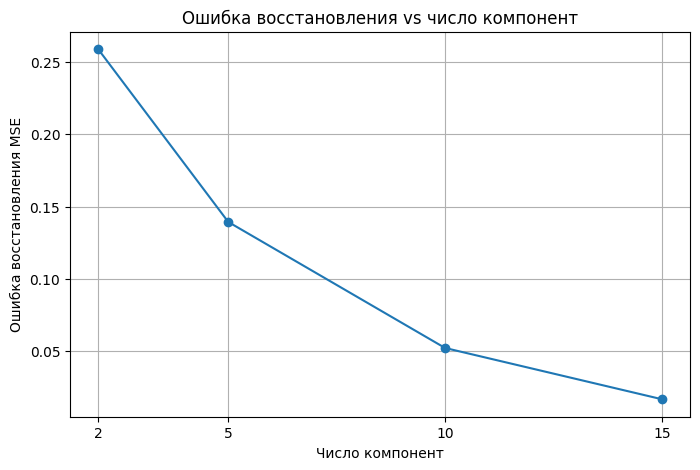

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(
    reconstruction_df['Число компонент'],
    reconstruction_df['Ошибка восстановления MSE'],
    marker='o'
)
plt.xlabel('Число компонент')
plt.ylabel('Ошибка восстановления MSE')
plt.title('Ошибка восстановления vs число компонент')
plt.xticks(k_values)
plt.show()

In [27]:
# Дополнительно можно посмотреть восстановление в исходном масштабе.
# Эта ошибка обычно хуже интерпретируется, потому что признаки имеют разные единицы измерения.
original_scale_results = []

for k in k_values:
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
    X_reduced = pca_k.fit_transform(X_scaled)
    X_reconstructed_scaled = pca_k.inverse_transform(X_reduced)
    X_reconstructed_original = scaler.inverse_transform(X_reconstructed_scaled)

    mse_original = mean_squared_error(X_filled.values, X_reconstructed_original)
    original_scale_results.append({
        'Число компонент': k,
        'MSE в исходном масштабе': mse_original
    })

original_scale_df = pd.DataFrame(original_scale_results)
display(original_scale_df)

,Число компонент,MSE в исходном масштабе
0,2,"3,034,623.2578"
1,5,"936,748.9724"
2,10,"305,605.9507"
3,15,"203,391.2996"


### Вывод по заданию 6

При `k = 2` ошибка восстановления самая большая, потому что данные описываются только двумя главными компонентами, а часть информации отбрасывается.

При увеличении числа компонент ошибка уменьшается.  
Это происходит потому, что каждая новая компонента добавляет часть дисперсии исходных данных.

Если использовать все компоненты, то стандартизированные данные можно восстановить почти полностью.  
Практически отличие может быть только из-за вычислительной погрешности.

Связь с объяснённой дисперсией прямая: чем больше накопленная объяснённая дисперсия, тем меньше ошибка восстановления.

Разумное число компонент можно выбирать по графику накопленной объяснённой дисперсии или по графику ошибки восстановления.  
Например, если после некоторого `k` ошибка уменьшается уже слабо, то это значение можно считать хорошим компромиссом между сжатием и сохранением информации.

## Задание 7. Итоговый анализ

Сформулируем общие выводы по лабораторной работе.

### Итоговые выводы

Снижение размерности играет важную роль в интеллектуальном анализе данных.  
Оно позволяет уменьшить число признаков, упростить визуализацию, убрать часть избыточной информации и иногда повысить устойчивость дальнейших моделей.

Уменьшение размерности не всегда полезно. Если отбросить слишком много компонент, можно потерять важную информацию. Это видно по ошибке восстановления: при малом числе компонент MSE заметно выше.

Линейные методы, такие как PCA, могут работать хуже нелинейных методов, если структура данных сложная и не описывается линейными направлениями. В таких случаях t-SNE и UMAP могут лучше показать локальные группы и скрытую структуру.

Преимущества и ограничения методов:

**PCA**

- преимущество: быстрый, понятный, хорошо интерпретируемый метод;
- преимущество: позволяет оценивать объяснённую дисперсию;
- ограничение: учитывает только линейные зависимости.

**t-SNE**

- преимущество: хорошо показывает локальные группы;
- ограничение: результат сильно зависит от параметров;
- ограничение: координаты сложно интерпретировать как новые признаки.

**UMAP**

- преимущество: часто хорошо сохраняет локальную и частично глобальную структуру;
- преимущество: обычно работает быстрее t-SNE на больших данных;
- ограничение: результат также зависит от параметров `n_neighbors` и `min_dist`.

По результатам работы можно сделать вывод, что в данном датасете есть избыточность признаков, а PCA позволяет заметно сократить размерность. При этом для визуального поиска групп полезно сравнивать PCA с нелинейными методами t-SNE и UMAP.